In [ ]:
!kaggle datasets download -d yasserh/wine-quality-dataset


Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
License(s): CC0-1.0
wine-quality-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
with zipfile.ZipFile('wine-quality-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('WineQT.csv',usecols=[0,10,11])


In [ ]:
df.sample(10)

,fixed acidity,alcohol,quality
675,9.0,11.3,6
1044,6.7,11.0,4
950,6.0,9.5,5
997,8.0,10.7,6
989,8.0,10.2,5
624,8.9,10.5,5
764,6.8,9.6,5
604,7.4,9.9,6
503,7.0,10.0,5
1,7.8,9.8,5


In [ ]:
df.columns = ['quality', 'alcohol', 'fixed acidity',]
# Note: Ensure the order matches your data.


In [ ]:
df

,quality,alcohol,fixed acidity
0,7.4,9.4,5
1,7.8,9.8,5
2,7.8,9.8,5
3,11.2,9.8,6
4,7.4,9.4,5
...,...,...,...
1138,6.3,11.0,6
1139,6.8,9.5,6
1140,6.2,10.5,5
1141,5.9,11.2,6


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('quality',axis=1),df['quality'],test_size=0.3,random_state=0)
x_train.shape,x_test.shape

((800, 2), (343, 2))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [ ]:
np.round(x_train_scaled.describe(), 1)

,alcohol,fixed acidity
count,800.0,800.0
mean,0.3,0.5
std,0.2,0.2
min,0.0,0.0
25%,0.2,0.4
50%,0.3,0.6
75%,0.4,0.6
max,1.0,1.0


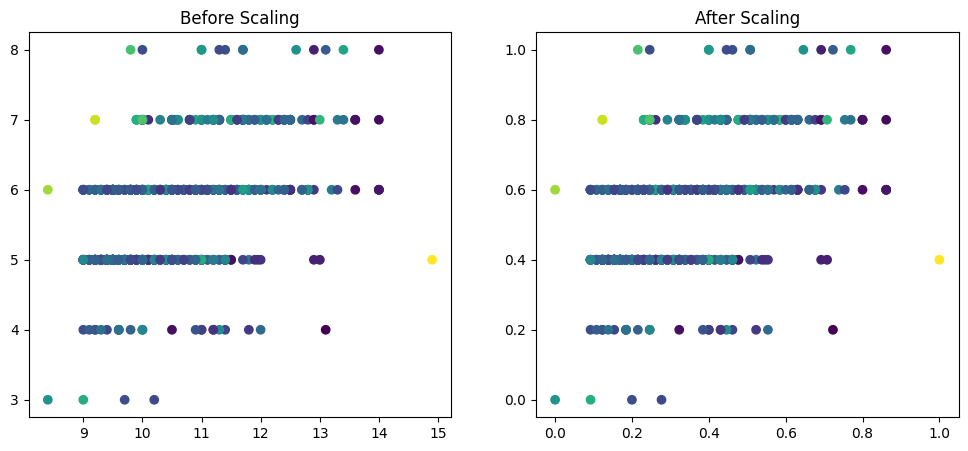

In [ ]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['alcohol'],x_train['fixed acidity'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['alcohol'],x_train_scaled['fixed acidity'],c=y_train)
ax2.set_title("After Scaling")
plt.show()
